In [1]:
import pandas as pd
import json
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from matplotlib import colors as mcolors

from  package_DBR import *
from Package_Lab import *
from package_OPTI import *


# Optimisation des paramètres Alpha et Gamma!

In [10]:
sp = 28
pv0 = 50
nombre_points = 10

best = Optimise_Auto(
    alpha_range=(0.01, 20),
    gamma_range=(0.01, 20),
    nombre_points=nombre_points,
    sp=sp,
    pv0=pv0,
    min_improvement=1,
    max_depth=10
)
print(f"Meilleur résultat : alpha={best[0]:.4f}, gamma={best[1]:.4f}, efficacité={best[2]:.4f}")

alpha = 20.0000, gamma = 2.2311, efficacité = 5303.2791
alpha = 20.0000, gamma = 0.8121, efficacité = 4262.9101
  depth=2 → score=4262.91 (amélioration=1040.37 pts IAE)
alpha = 20.0000, gamma = 1.1497, efficacité = 4138.1406
  depth=3 → score=4138.14 (amélioration=124.77 pts IAE)
alpha = 20.0000, gamma = 1.2538, efficacité = 4112.4292
  depth=4 → score=4112.43 (amélioration=25.71 pts IAE)
alpha = 20.0000, gamma = 1.2972, efficacité = 4104.5058
  depth=5 → score=4104.51 (amélioration=7.92 pts IAE)
alpha = 20.0000, gamma = 1.2994, efficacité = 4104.1166
  depth=6 → score=4104.12 (amélioration=0.39 pts IAE)
  ✓ Convergé à depth=5 (amélioration < 1 pts)
Meilleur résultat : alpha=20.0000, gamma=1.2972, efficacité=4104.5058


# Test de Alpha et Gamma

4056.432406764421


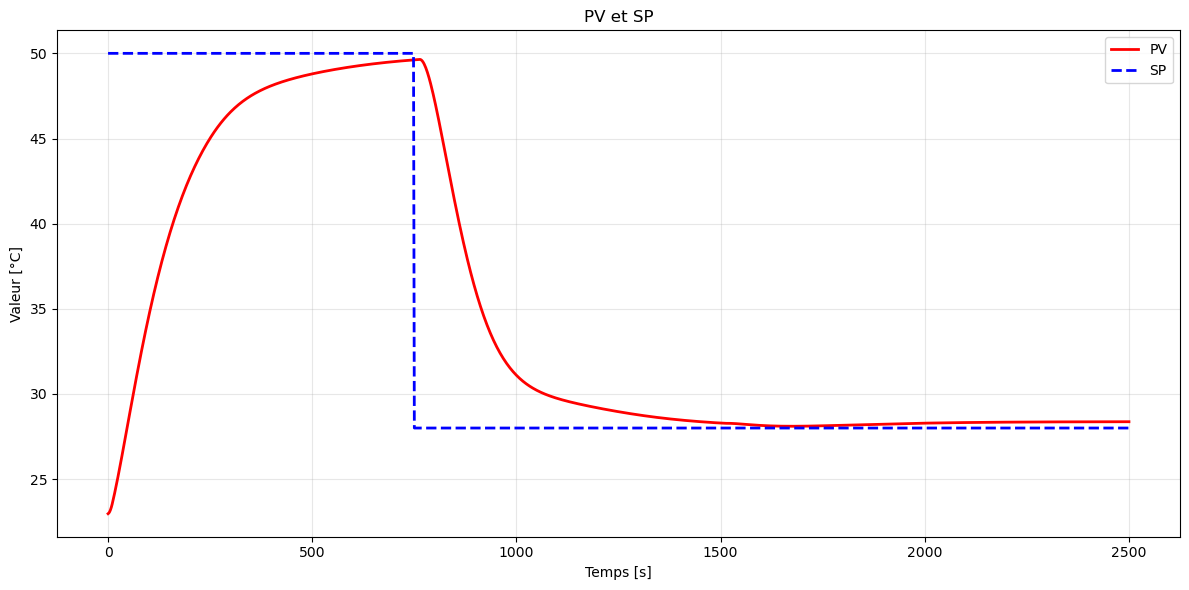

In [15]:
response = Signal_Response(alpha=100000000,gamma=1.119,sp=sp,pv0=pv0)[0]
print(calc_efficacité(response))
plot_pv_sp(response["t"],response["PV"],response["SP"],"PV et SP")

# Calcul de la table d'optimisation Alpha(step) Gamma(step) avec step = SP-PV0

In [ ]:
Calibration = build_calibration(
    step_range=(-50, 50), 
    pv0=50,
    nombre_steps=51,
    alpha_range=(0.01, 20.0),
    gamma_range=(0.01, 5.0),
    nombre_points=10,
    min_improvement=1,
    max_depth=10
)
print("Calibration optimale :", Calibration)
print(interpolation(sp=80, pv0=50, dico=Calibration))


Optimisation pour step=-50.0°C (SP=0.0, PV0=50)...
alpha = 2.2311, gamma = 3.3367, efficacité = 26855.7850
alpha = 2.4162, gamma = 3.1981, efficacité = 26854.6958
  depth=2 → score=26854.70 (amélioration=1.09 pts IAE)
alpha = 2.2774, gamma = 3.3713, efficacité = 26854.4292
  depth=3 → score=26854.43 (amélioration=0.27 pts IAE)
  ✓ Convergé à depth=2 (amélioration < 1 pts)
Optimisation pour step=-48.0°C (SP=2.0, PV0=50)...
alpha = 2.2311, gamma = 2.7822, efficacité = 25108.0518
alpha = 2.4162, gamma = 3.1981, efficacité = 25103.1827
  depth=2 → score=25103.18 (amélioration=4.87 pts IAE)
alpha = 2.5550, gamma = 3.0941, efficacité = 25104.4326
  depth=3 → score=25104.43 (amélioration=1.25 pts IAE)
alpha = 2.3815, gamma = 3.1721, efficacité = 25102.9424
  depth=4 → score=25102.94 (amélioration=1.49 pts IAE)
alpha = 2.4075, gamma = 3.1872, efficacité = 25102.8818
  depth=5 → score=25102.88 (amélioration=0.06 pts IAE)
  ✓ Convergé à depth=4 (amélioration < 1 pts)
Optimisation pour step=-46.0

NameError: name 'output' is not defined

# Mise a jour automatique de alpha et gamma basé sur le dictionnaire mis en place 

In [ ]:
step, alpha, gamma = interpolation(sp, pv0, dico=Calibration)
response = Signal_Response(alpha=alpha,gamma=gamma,sp=sp,pv0=pv0)[0]
print("Interpolated parameters : alpha =", alpha, ", gamma =", gamma)
print(calc_efficacité(response))
plot_pv_sp(response["t"],response["PV"],response["SP"],"PV et SP")

# Vérification que alpha et gamma ne sont fonction que du step(sp-pv0) et non de sp et pv0 séparément

In [ ]:

alpha_range = (0.01, 10)
gamma_range = (0.01, 10)
nombre_points = 5
depth = 2
calibration = {}

positive_step_values = np.arange(0, 90, 10)
negative_step_values = np.arange(100, 10, -10)
print("Steps testés :", positive_step_values, negative_step_values)

for step in positive_step_values:
    best, _ = Recursive_Optimise(alpha_range, gamma_range, nombre_points, sp=step+10, pv0=step, depth=depth)
    alpha, gamma, _ = best
    calibration[step] = {'alpha': alpha, 'gamma': gamma}
    print(f"step={step} → α={alpha:.4f}, γ={gamma:.4f}")

for step in negative_step_values:
    best, _ = Recursive_Optimise(alpha_range, gamma_range, nombre_points, sp=step-5, pv0=step, depth=depth)
    alpha, gamma, _ = best
    calibration[step] = {'alpha': alpha, 'gamma': gamma}
    print(f"step={step} → α={alpha:.4f}, γ={gamma:.4f}")

print("\nCALIBRATION FINALE :")
for step in sorted(calibration.keys()):
    params = calibration[step]
    print(f"step {step}: {{'alpha': {params['alpha']:.4f}, 'gamma': {params['gamma']:.4f}}}")



# Plot de l'hypothèse de alpha et gamma cst pour un step constant

In [ ]:
positifs = {
    0: {'alpha': 2.5075, 'gamma': 0.6344},
    10: {'alpha': 2.5075, 'gamma': 0.6344},
    20: {'alpha': 2.5075, 'gamma': 0.6344},
    30: {'alpha': 2.5075, 'gamma': 0.6344},
    40: {'alpha': 2.5075, 'gamma': 0.6344},
    50: {'alpha': 2.5075, 'gamma': 0.6344},
    60: {'alpha': 2.5075, 'gamma': 0.6344},
    70: {'alpha': 2.5075, 'gamma': 0.6344},
    80: {'alpha': 2.5075, 'gamma': 0.6344}
}

negatifs = {
    100: {'alpha': 1.2588, 'gamma': 0.6344},
    90: {'alpha': 1.2588, 'gamma': 0.6344},
    80: {'alpha': 1.2588, 'gamma': 0.6344},
    70: {'alpha': 1.2588, 'gamma': 0.6344},
    60: {'alpha': 1.2588, 'gamma': 0.6344},
    50: {'alpha': 1.2588, 'gamma': 0.6344},
    40: {'alpha': 1.2588, 'gamma': 0.6344},
    30: {'alpha': 1.2588, 'gamma': 0.6344},
    20: {'alpha': 1.2588, 'gamma': 0.6344}
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Alpha
steps_pos = list(positifs.keys())
alpha_pos = [positifs[s]['alpha'] for s in steps_pos]
ax1.plot(steps_pos, alpha_pos, 'go-', linewidth=2, markersize=8, label='Positifs')

steps_neg = list(negatifs.keys())
alpha_neg = [negatifs[s]['alpha'] for s in steps_neg]
ax1.plot(steps_neg, alpha_neg, 'ro-', linewidth=2, markersize=8, label='Négatifs')

ax1.set_xlabel('Step')
ax1.set_ylabel('Alpha')
ax1.set_title('Alpha vs Step')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Gamma (plateau partout)
gamma_pos = [positifs[s]['gamma'] for s in steps_pos]
ax2.plot(steps_pos, gamma_pos, 'go-', linewidth=2, markersize=8, label='Positifs')
gamma_neg = [negatifs[s]['gamma'] for s in steps_neg]
ax2.plot(steps_neg, gamma_neg, 'ro-', linewidth=2, markersize=8, label='Négatifs')

ax2.set_xlabel('Step')
ax2.set_ylabel('Gamma')
ax2.set_title('Gamma vs Step (constant 0.6344)')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.savefig('alpha_gamma_calibration.png', dpi=300)
plt.show()

# Plot Alpha et Gamma en fonction du step

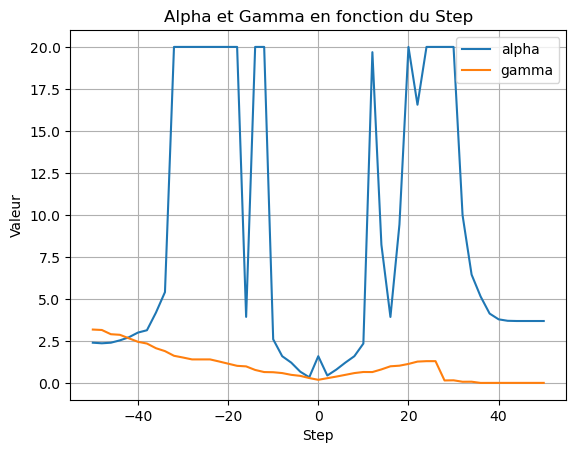

In [2]:
steps = sorted(calibration.keys())
alphas = [calibration[s]['alpha'] for s in steps]
gammas = [calibration[s]['gamma'] for s in steps]

# ===== PLOT =====
plt.figure()

plt.plot(steps, alphas, label="alpha")
plt.plot(steps, gammas, label="gamma")

plt.xlabel("Step")
plt.ylabel("Valeur")
plt.title("Alpha et Gamma en fonction du Step")
plt.legend()
plt.grid()

plt.show()

# Recalcul des points erronés ! 

In [20]:
non_converged = [-22, -18, -16, -14, -10, 10, 14, 18, 20, 32, 34, 36, 38, 40, 42, 44, 46, 48, 50]
for step in non_converged:
    pv0 = 50
    sp = pv0 + step

    best = Optimise_Auto(
        alpha_range=(0.001, 20),
        gamma_range=(0.001, 5),
        nombre_points=10,
        sp=sp,
        pv0=pv0,
        min_improvement=1,
        max_depth=10
    )
    print(f"step={step} → alpha={best[0]:.4f}, gamma={best[1]:.4f}, efficacité={best[2]:.4f}")
    
    Calibration[float(step)] = {'alpha': best[0], 'gamma': best[1]}

alpha = 20.0000, gamma = 1.1119, efficacité = 4150.4355
alpha = 20.0000, gamma = 1.3125, efficacité = 4120.3675
  depth=2 → score=4120.37 (amélioration=30.07 pts IAE)
alpha = 20.0000, gamma = 1.2778, efficacité = 4107.9805
  depth=3 → score=4107.98 (amélioration=12.39 pts IAE)
alpha = 20.0000, gamma = 1.2864, efficacité = 4106.4327
  depth=4 → score=4106.43 (amélioration=1.55 pts IAE)
alpha = 20.0000, gamma = 1.2973, efficacité = 4104.4893
  depth=5 → score=4104.49 (amélioration=1.94 pts IAE)
alpha = 20.0000, gamma = 1.3000, efficacité = 4104.0027
  depth=6 → score=4104.00 (amélioration=0.49 pts IAE)
  ✓ Convergé à depth=5 (amélioration < 1 pts)
step=-22 → alpha=20.0000, gamma=1.2973, efficacité=4104.4893
alpha = 20.0000, gamma = 1.1119, efficacité = 3483.9467
alpha = 20.0000, gamma = 1.0502, efficacité = 3415.2224
  depth=2 → score=3415.22 (amélioration=68.72 pts IAE)
alpha = 20.0000, gamma = 1.0155, efficacité = 3416.3018
  depth=3 → score=3416.30 (amélioration=1.08 pts IAE)
alpha = 